# AI Agent for Chicago Crime Analysis

This notebook walks you through building a "Code Agent" capable of performing geographic data analysis. Using the `smolagents` library from Hugging Face, we'll create an assistant that can analyze real-world crime data from the City of Chicago.

The agent will answer plain-English questions by writing and executing Python code, using the **geopandas** library to perform spatial queries and generate maps to visualize the results.

### **How It Works**

The agent operates in a loop:
1.  **Plan:** It analyzes your request and creates a step-by-step plan.
2.  **Code:** It writes Python code to execute the current step, using the tools you provide.
3.  **Execute:** It runs the code and observes the outcome.
4.  **Repeat:** It continues this process until your request is fully addressed.

Let's get started!

## 1. Environment Setup

First, we'll install the necessary libraries and configure our environment.

#### **Install Libraries**

This command installs `smolagents` for our AI agent, `geopandas` for spatial operations, `matplotlib` for plotting, and `geodatasets` for sample data.

In [1]:
# Cell 1: Install Libraries
!pip install smolagents geopandas matplotlib geodatasets -q

#### **Set Up Hugging Face API Token**

The agent uses a powerful language model from the Hugging Face Hub. To access it, you need an API token.

1.  If you don't have one, create a free Hugging Face account and get a token from your [**profile settings**](https://huggingface.co/settings/tokens).
2.  Run the cell below. A text field will appear.
3.  Paste your token into the field and press Enter. The token will be hidden for security.

This will load the token and initialize the agent's brain (the language model).

In [2]:
# Cell 2: Import Libraries and Set API Token
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from smolagents import CodeAgent, tool
from smolagents.models import InferenceClientModel
import getpass

# Prompt for the Hugging Face API token
hf_token = getpass.getpass('🔑 Please enter your Hugging Face API token: ')
os.environ['HF_TOKEN'] = hf_token

if hf_token:
    print("✅ Hugging Face API token has been set.")
else:
    print("⚠️ Hugging Face API token was not provided.")

# Initialize the model that will power our agent
# This uses the HF_TOKEN environment variable automatically
model = InferenceClientModel()

print("🤖 Model initialized.")

🔑 Please enter your Hugging Face API token:  ········


✅ Hugging Face API token has been set.
🤖 Model initialized.


## 2. Create the Agent's "Skills" (Tools)

Next, we define the specific functions our agent is allowed to use. Each function is a "tool" decorated with `@tool`. The agent reads the function's description (the docstring) to understand what it does and how to use it.

In [18]:
# Cell 3: Define Spatial Tools

@tool
def load_chicago_community_areas() -> gpd.GeoDataFrame:
    """
    Loads the official boundaries for Chicago's 77 community areas.
    Returns a GeoDataFrame with geometry and community area information.
    """
    url = 'https://raw.githubusercontent.com/RandomFractals/ChicagoCrimes/refs/heads/master/data/chicago-community-areas.geojson'
    return gpd.read_file(url)
@tool
def load_chicago_crime_data() -> gpd.GeoDataFrame:
    """
    Loads reported crime incidents in Chicago from the last 365 days.
    The data includes coordinates for each crime, which can be used for mapping.
    Returns a GeoDataFrame with crime details and point geometries.
    """
    # Socrata API endpoint for crime data. 
    # The space ' ' is encoded as %20 and the greater-than '>' is encoded as %3E.
    url = "https://data.cityofchicago.org/resource/ijzp-q8t2.json?$where=date%20%3E%20'2024-08-13T00:00:00.000'&$limit=50000"
    df = pd.read_json(url)
    # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326"
    )
    return gdf
@tool
def filter_dataframe_by_value(df: pd.DataFrame, column: str, value: str) -> pd.DataFrame:
    """
    Filters a DataFrame to only include rows where the specified column matches a certain value.
    This is useful for isolating specific types of crime, for example.
    Args:
        df: The DataFrame to filter.
        column: The name of the column to check.
        value: The value to match in the column.
    Returns:
        A filtered DataFrame.
    """
    return df[df[column].str.upper() == value.upper()]

@tool
def spatial_join_and_count(gdf_polygons: gpd.GeoDataFrame, gdf_points: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Performs a spatial join, counting how many points from one GeoDataFrame fall within the polygons of another.
    For example, it can count the number of thefts (points) in each community area (polygons).
    Args:
        gdf_polygons: The GeoDataFrame with polygons (e.g., community areas).
        gdf_points: The GeoDataFrame with points to be counted (e.g., crimes).
    Returns:
        The polygon GeoDataFrame with a new 'crime_count' column.
    """
    # Ensure both GeoDataFrames use the same CRS
    gdf_points = gdf_points.to_crs(gdf_polygons.crs)
    # Perform the spatial join
    joined_gdf = gpd.sjoin(gdf_polygons, gdf_points, how="left", predicate='contains')
    # Count points in each polygon
    point_counts = joined_gdf.groupby('community').size()
    point_counts.name = 'crime_count'
    # Merge the counts back into the original polygon gdf
    result_gdf = gdf_polygons.merge(point_counts, left_on='community', right_index=True, how='left').fillna(0)
    result_gdf['crime_count'] = result_gdf['crime_count'].astype(int)
    return result_gdf

@tool
def plot_choropleth_map(gdf: gpd.GeoDataFrame, column: str, title: str) -> None:
    """
    Generates and displays a choropleth map, where polygons are colored based on a numeric value.
    This is excellent for visualizing data like crime rates across different areas.
    Args:
        gdf: The GeoDataFrame containing the geographic data and the values to plot.
        column: The name of the column to use for coloring the polygons.
        title: The title to display above the map.
    """
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    gdf.plot(column=column, ax=ax, legend=True,
             legend_kwds={'label': "Number of Crimes", 'orientation': "horizontal"})
    ax.set_title(title, fontdict={'fontsize': '16', 'fontweight': '3'})
    ax.set_axis_off()
    plt.show()

print("✅ Agent's spatial tools are defined.")

✅ Agent's spatial tools are defined.


## 3. Build and Run the Agent

With our tools defined, we can now assemble the agent. We create a `CodeAgent` and pass it the list of tools it's allowed to use.

In [19]:
# Cell 4: Create the Spatial Agent
spatial_agent = CodeAgent(
    tools=[
        load_chicago_community_areas,
        load_chicago_crime_data,
        filter_dataframe_by_value,
        spatial_join_and_count,
        plot_choropleth_map,
    ],
    model=model,
)

print("🤖 Spatial Agent is built and ready for commands!")

🤖 Spatial Agent is built and ready for commands!


## 4. Perform Crime Analysis

Now, let's give our agent a real-world analysis task. The agent will need to plan and execute multiple steps, using several of its tools in sequence to arrive at the final answer.

#### **Task: Analyze Thefts by Community Area**

We'll ask the agent to identify which Chicago community areas have the highest number of reported thefts. This requires loading both datasets, filtering for a specific crime type, joining the data spatially, and then visualizing the result.

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ I want to analyze theft in Chicago. First, load the community area boundaries and the latest crime data. Then,  │
│ isolate only the crimes that are of the primary type 'THEFT'. Next, determine how many of these thefts occurred │
│ in each community area. Finally, list the top 10 community areas with the most thefts and create a map that     │
│ visualizes the theft counts across all of Chicago.                                                              │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  community_areas_gdf = load_chicago_community_areas()                                                             
  crime_data_gdf = load_chicago_crime_data()                                                                       
                                                                                                                   
  # Confirming the column names of Community Areas and Crime Data for later operations                             
  print("Community Areas columns:", community_areas_gdf.columns.tolist())                                          
  print("Crime Data columns:", crime_data_gdf.columns.tolist())                                                    
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Community Areas columns: ['community', 'area', 'shape_area', 'perimeter', 'area_num_1', 'area_numbe', 'comarea_id',
'comarea', 'shape_len', 'geometry']
Crime Data columns: ['id', 'case_number', 'date', 'block', 'iucr', 'primary_type', 'description', 
'location_description', 'arrest', 'domestic', 'beat', 'district', 'ward', 'community_area', 'fbi_code', 
'x_coordinate', 'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude', 'location', 'geometry']

Out: None

[Step 1: Duration 6.90 seconds| Input tokens: 2,421 | Output tokens: 184]

...

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  # Filtering the crime data for thefts                                                                            
  theft_crime_data_gdf = filter_dataframe_by_value(df=crime_data_gdf, column='primary_type', value='THEFT')        
                                                                                                                   
  # Performing a spatial join count to get theft counts per community area                                         
  theft_counts_gdf = spatial_join_and_count(gdf_polygons=community_areas_gdf, gdf_points=theft_crime_data_gdf)     
  theft_counts_gdf['theft_count'] = theft_counts_gdf.index                                                         
                                                                                                                   
  # Sorting communities by theft count descending                                                                  
  top_10_theft_communities = theft_counts_gdf.sort_values(by='theft_count', ascending=False).head(10)              
                                                                                                                   
  # Printing top 10 communities with most thefts                                                                   
  print("Top 10 communities with most thefts:\n", top_10_theft_communities[['community',                           
  'theft_count']].reset_index(drop=True))                                                                          
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Top 10 communities with most thefts:
             community  theft_count
0         EDISON PARK           76
1           EDGEWATER           75
2               OHARE           74
3         MORGAN PARK           73
4     MOUNT GREENWOOD           72
5  WASHINGTON HEIGHTS           71
6             BEVERLY           70
7      AUBURN GRESHAM           69
8             ASHBURN           68
9        LINCOLN PARK           67

Out: None

[Step 2: Duration 4.37 seconds| Input tokens: 5,286 | Output tokens: 458]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  # Ensure that the GeoDataFrame is properly merged with the theft counts                                          
  theft_counts_gdf = theft_counts_gdf.reset_index(drop=True)                                                       
  theft_counts_gdf = theft_counts_gdf.set_geometry('geometry')                                                     
  theft_counts_gdf = theft_counts_gdf.fillna(0)  # Replace NaN values with zero for plotting                       
                                                                                                                   
  # Plotting the choropleth map of theft counts in Chicago community areas                                         
  plot_choropleth_map(gdf=theft_counts_gdf, column='theft_count', title='Theft Counts Across Chicago Community     
  Areas')                                                                                                          
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

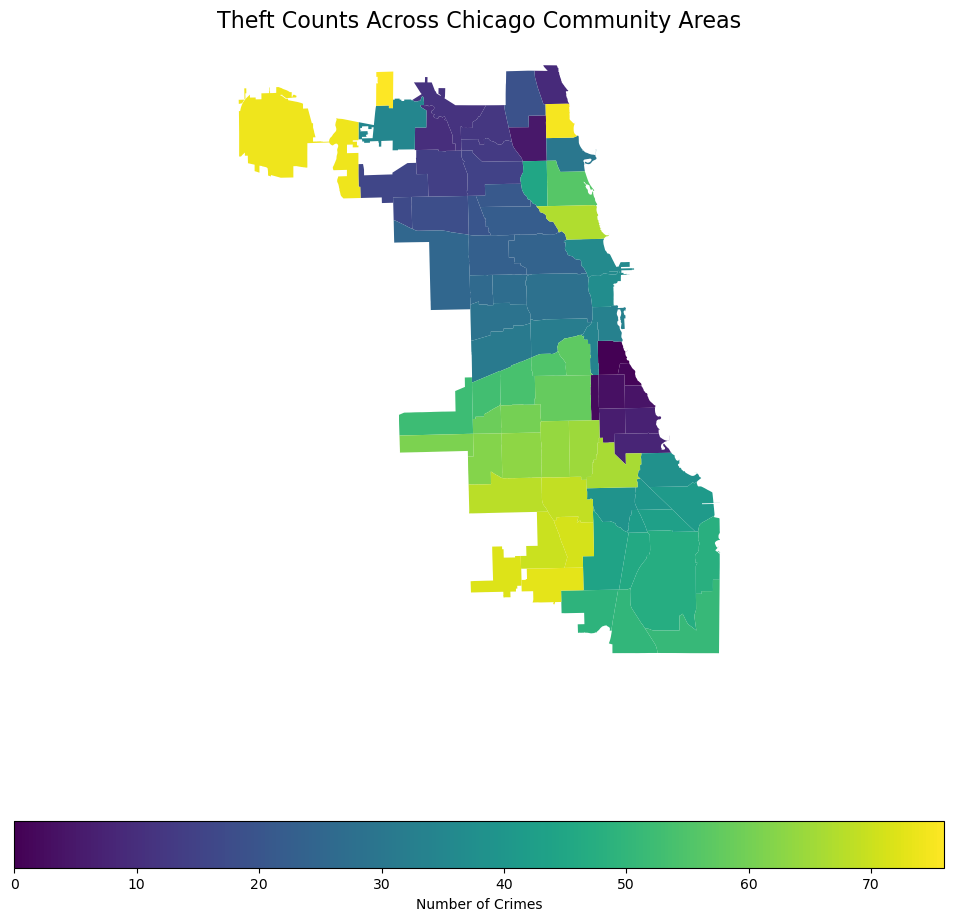

Out: None

[Step 3: Duration 2.73 seconds| Input tokens: 8,802 | Output tokens: 638]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 4 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  # Preparing the final answer as a string                                                                         
  final_top_10_communities = top_10_theft_communities[['community', 'theft_count']].to_string(index=False)         
                                                                                                                   
  # Return the final answer                                                                                        
  final_answer(final_top_10_communities)                                                                           
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer:          community  theft_count
       EDISON PARK           76
         EDGEWATER           75
             OHARE           74
       MORGAN PARK           73
   MOUNT GREENWOOD           72
WASHINGTON HEIGHTS           71
           BEVERLY           70
    AUBURN GRESHAM           69
           ASHBURN           68
      LINCOLN PARK           67

[Step 4: Duration 1.86 seconds| Input tokens: 12,675 | Output tokens: 762]

'         community  theft_count\n       EDISON PARK           76\n         EDGEWATER           75\n             OHARE           74\n       MORGAN PARK           73\n   MOUNT GREENWOOD           72\nWASHINGTON HEIGHTS           71\n           BEVERLY           70\n    AUBURN GRESHAM           69\n           ASHBURN           68\n      LINCOLN PARK           67'

In [20]:
# Cell 5: Main Analysis Task
spatial_agent.run(
    "I want to analyze theft in Chicago. First, load the community area boundaries and the latest crime data. "
    "Then, isolate only the crimes that are of the primary type 'THEFT'. "
    "Next, determine how many of these thefts occurred in each community area. "
    "Finally, list the top 10 community areas with the most thefts and create a map that visualizes the theft counts across all of Chicago."
)

This concludes the demonstration. You can now experiment with your own commands, such as asking about different crime types or combining tools in new ways!